In [1]:
from chembayes import Optimizer
import pandas as pd

c:\Users\jamar\Documents\05_PYTHON PROJECTS\chembayes\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Example data loading
data = pd.read_csv('data/test_data.csv')

In [15]:
data

,x1_num_std_normal,x2_num_uniform_m50_50,x3_num_lognormal,x4_num_exponential,x5_num_shifted_normal,c1_cat_ABC,c2_cat_XY,c3_cat_colors,y1,y2,y3,objective
0,0.304717,-23.413004,2.707860,12.542484,110.601294,C,X,green,-1.827227,-0.835750,-0.397587,-1.987559
1,-1.039984,46.917638,2.404682,12.681845,85.906535,C,Y,purple,2.999333,6.040927,1.697861,1.160146
2,0.750451,27.875090,3.501463,3.372740,96.407772,A,X,orange,3.804071,5.992363,2.627563,1.592895
3,0.940565,21.689019,7.811612,8.689367,103.935522,A,Y,blue,2.786430,3.848984,1.497805,0.700270
4,-1.951035,-5.063850,2.909376,30.781850,116.410570,B,X,purple,1.282209,3.942867,1.500168,0.189963
...,...,...,...,...,...,...,...,...,...,...,...,...
95,-1.447112,37.456204,0.396534,42.569109,109.079312,A,Y,red,1.863651,5.957251,0.603711,0.562369
96,-1.322700,-30.356533,2.275870,0.527184,93.826539,B,X,purple,-0.273600,1.006240,0.185088,-1.049601
97,-0.997247,-18.967633,3.103046,53.296195,118.710943,B,X,red,1.697145,3.350913,0.324144,0.038695
98,0.399774,27.740484,3.393954,0.634325,63.371878,A,X,red,3.207384,4.447830,1.738293,0.984544


In [3]:
# Inputs selection
inputs = [
    'x1_num_std_normal',
    'x2_num_uniform_m50_50',
    'x3_num_lognormal',
    'x4_num_exponential',
    'x5_num_shifted_normal',
    'c1_cat_ABC',
    'c2_cat_XY',
    'c3_cat_colors'
]

In [ ]:
# Single output optimization
opt = Optimizer(data=data, inputs=inputs, output='y1')

In [5]:
opt.summary()


--- Optimization results ---
Model score (R²): 0.9225
Best input parameters:
  x1_num_std_normal: 1.4650226750255941
  x2_num_uniform_m50_50: 49.235266724238805
  x3_num_lognormal: 11.87932333563974
  x4_num_exponential: 116.49046324251609
  x5_num_shifted_normal: 100.38886848397132
  c1_cat_ABC: B
  c2_cat_XY: X
  c3_cat_colors: green
Best predicted y1: 6.4884 ± 1.3022


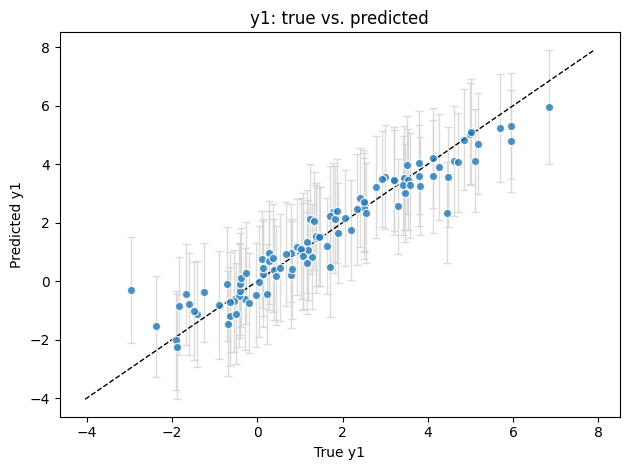

In [ ]:
opt.true_vs_pred_plot()

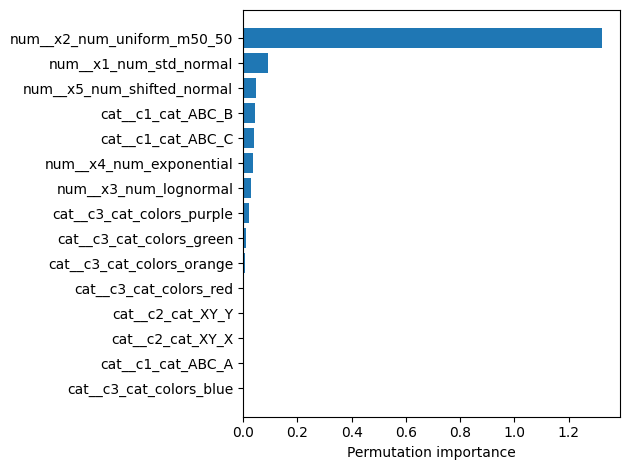

In [7]:
opt.permutation_importance_plot()

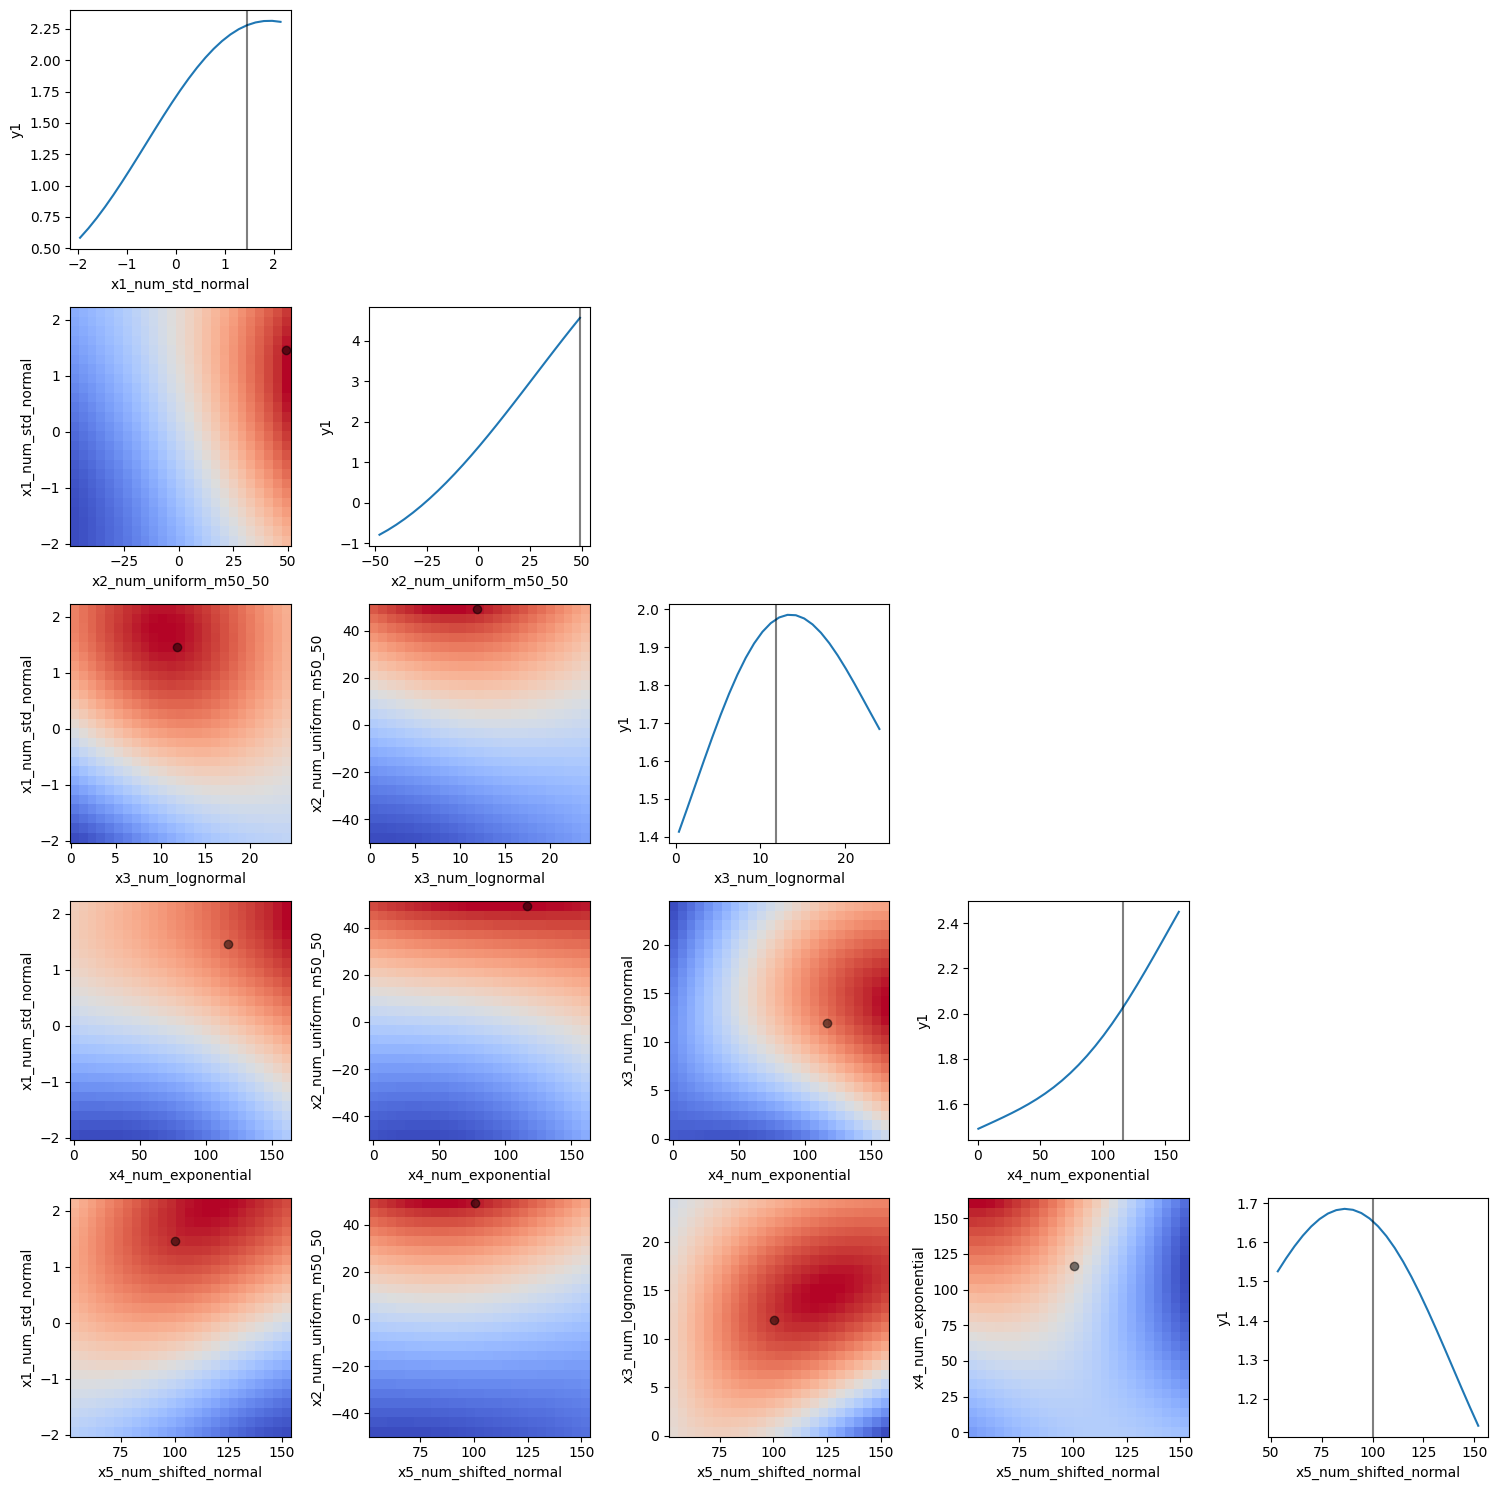

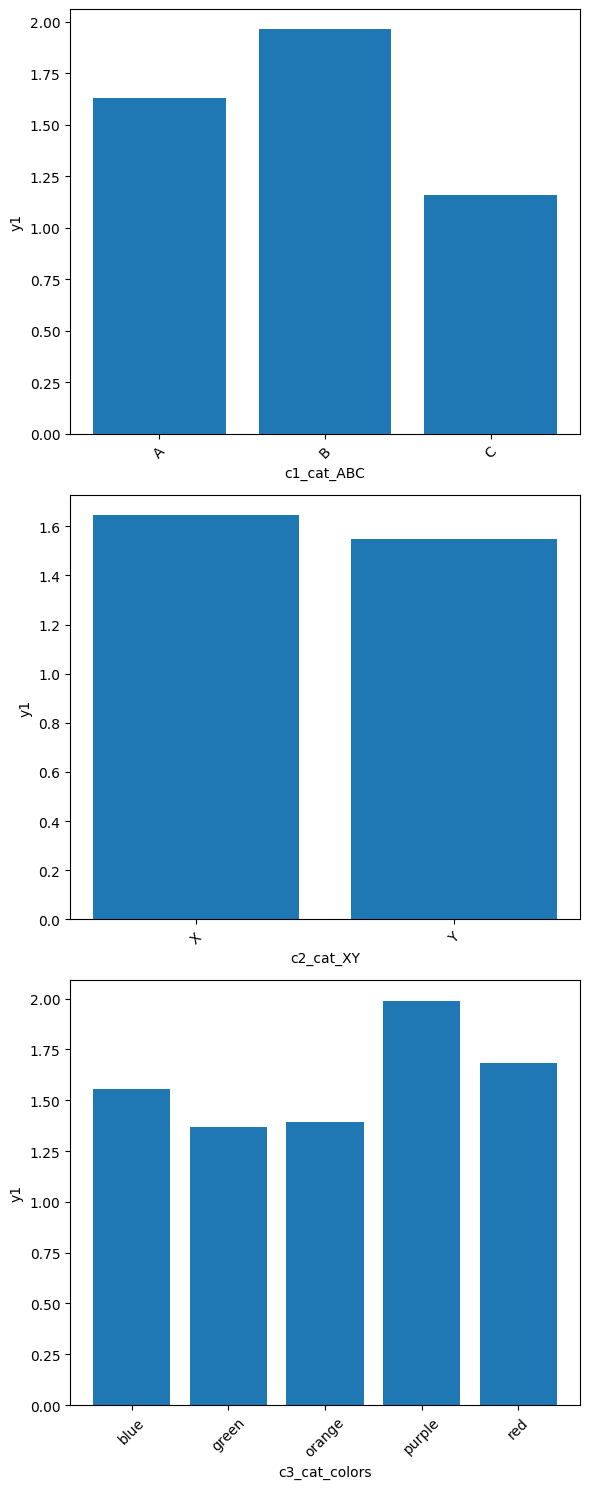

In [8]:
opt.partial_dependence_plot()

In [9]:
# Weighted outputs optimization
outputs = {
    'y1': 0.75,
    'y2': 0.5,
    'y3': 0.25
}

In [10]:
opt2 = Optimizer(data, inputs=inputs, output=outputs)

In [11]:
opt2.summary()


--- Optimization results ---
Model score (R²): 0.9799
Best input parameters:
  x1_num_std_normal: 1.9530948161230741
  x2_num_uniform_m50_50: 45.74124188689265
  x3_num_lognormal: 6.252069871847442
  x4_num_exponential: 133.19241599802797
  x5_num_shifted_normal: 78.73446145471212
  c1_cat_ABC: B
  c2_cat_XY: X
  c3_cat_colors: red
Best predicted objective: 3.0384 ± 0.6699


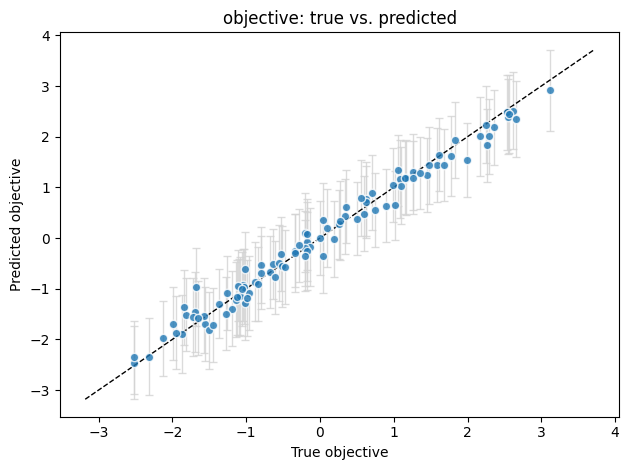

In [12]:
opt2.plot_true_vs_pred()

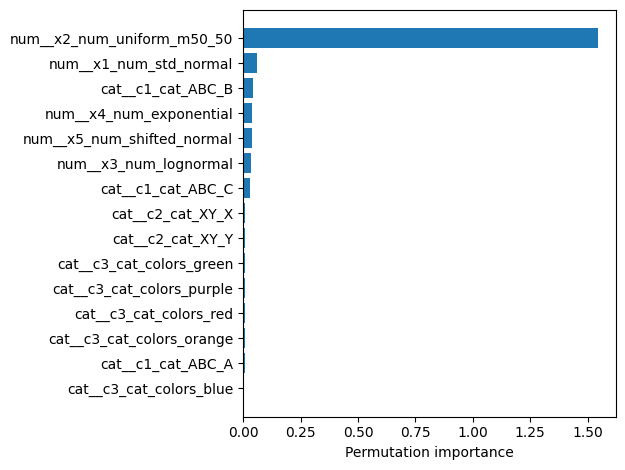

In [13]:
opt2.permutation_importance_plot()

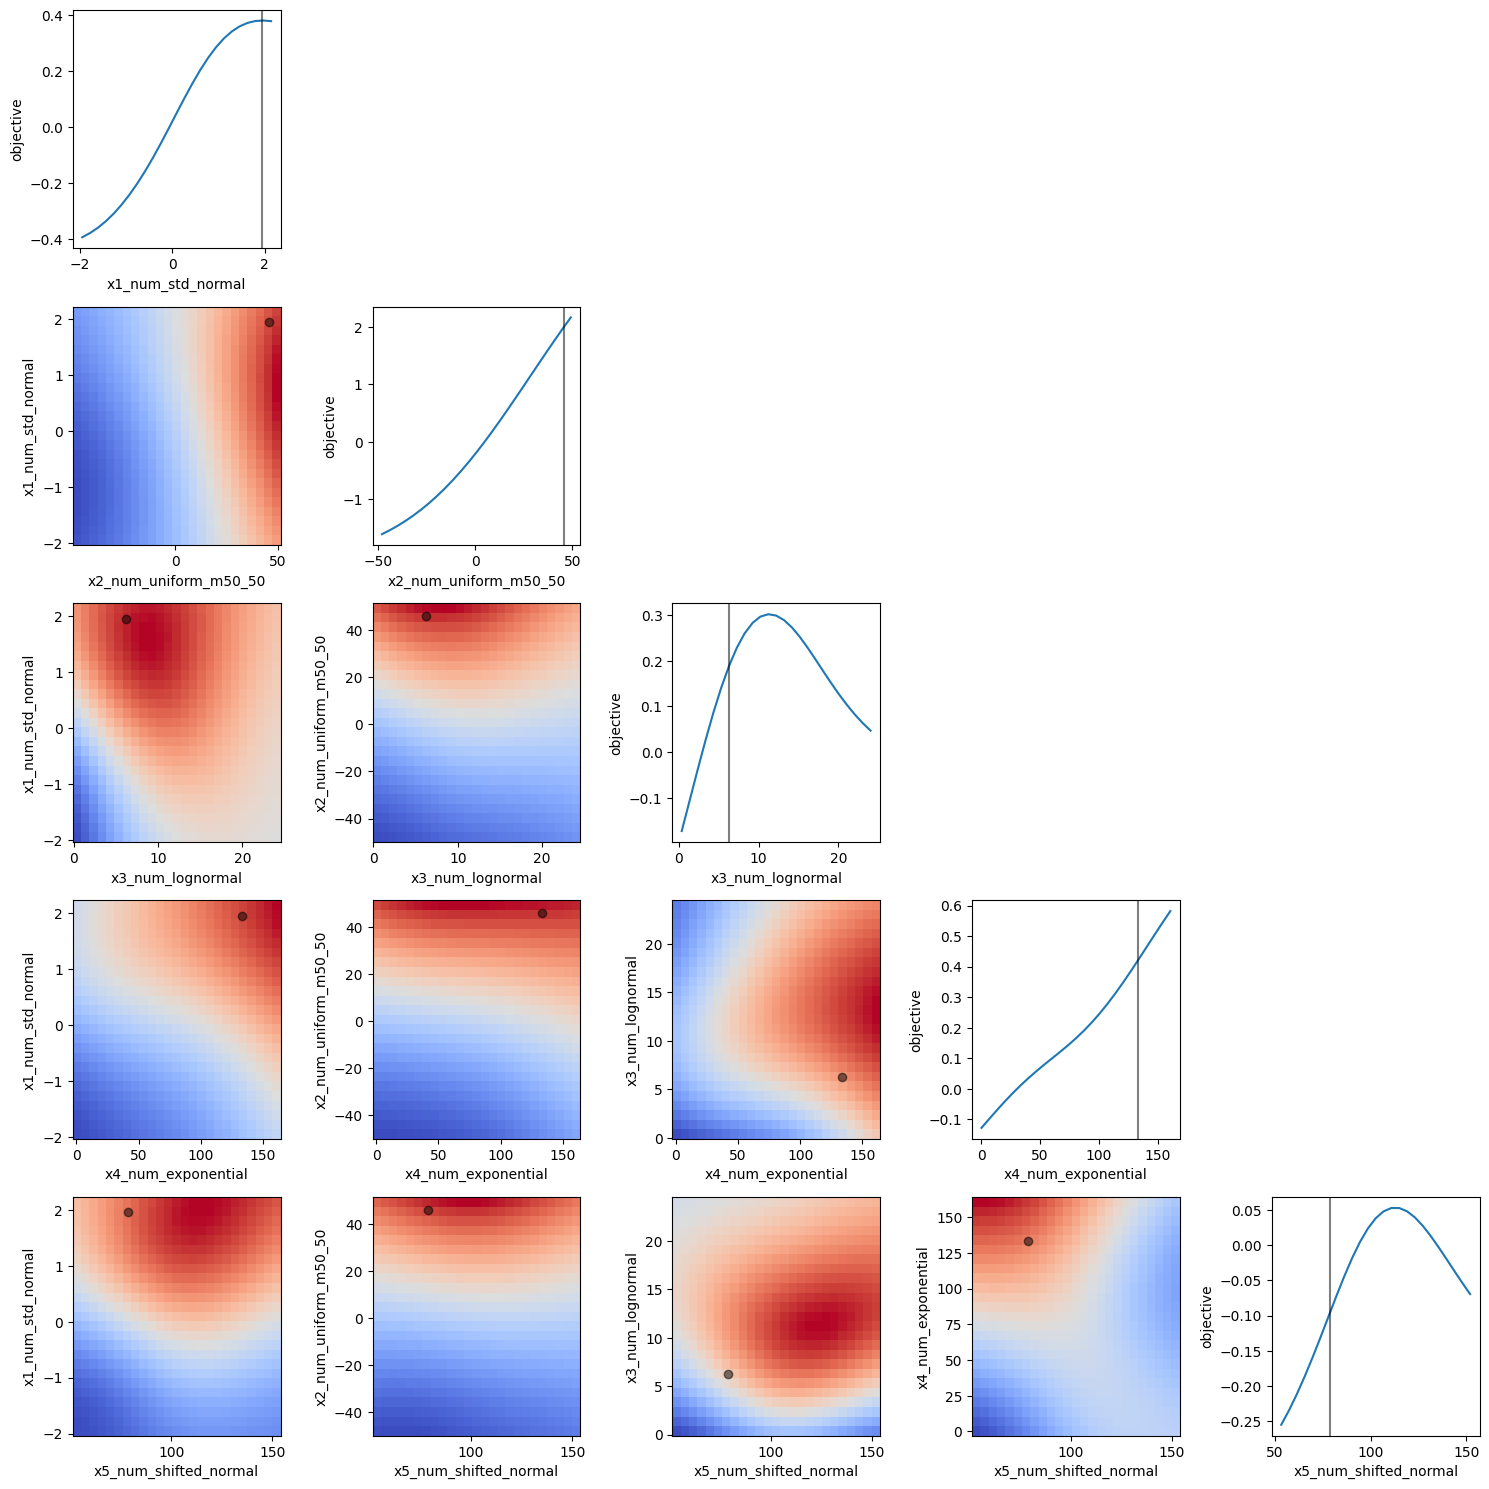

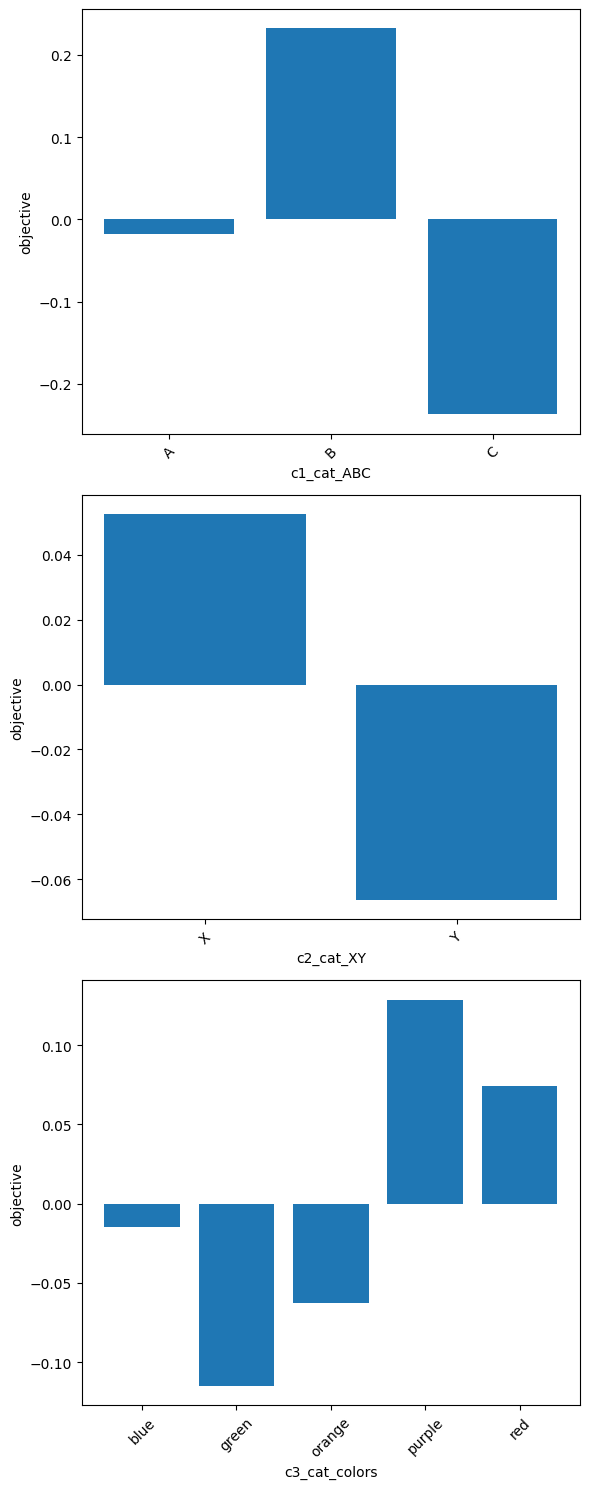

In [14]:
opt2.partial_dependence_plot()